# Notebook 19 — Multi-tracer joint loss on Eq Pacific (Track 1 v1.8)

**Goal.** nb15 showed DINNDeep saturates Eq Pacific FeT to r=1.000 with degenerate Carroll-6 recovery (the network finds *a* per-cell parameter set that produces the FeT field, but not Carroll's published set). nb18 reproduced this on N Pacific Chl with mixed Carroll-6 recovery (3 closer, 3 worse). The shared diagnosis: **single-target fits underdetermine the Carroll-6 vector** — many parameter combinations produce the same one tracer field, so the network picks one, and there's no reason it should be Carroll's.

**Question for nb19:** does adding *multiple* tracer fields as joint loss surfaces collapse this degeneracy?

**Hypothesis.** With a single target, the inverse problem has many solutions. With four tracers constraining the same Carroll-6 vector simultaneously, the solution set shrinks. If the published Carroll-6 is the unique vector that produces all four observed fields, joint loss should recover it (or close to it).

**Setup.** Same Eq Pacific AOI, same DINNDeep architecture, same hyperparameters as nb15. Only the loss function changes.

**Loss target — 4 tracers from carroll6's existing 5-tracer state vector:**

| State component | Maps to Darwin output |
|---|---|
| `state[0]` (DFe) | `FeT` (LLC270 monthly) |
| `state[1] + state[2]` (Ps + Pl) | `Chl_total` (bin_average sum of Chl1–Chl5) |
| `state[3]` (POC) | `POC` (LLC270 monthly) |
| `state[4]` (PIC) | `PIC` (LLC270 monthly) |

**Loss = mean over 4 tracers of z-scored MSE.** No box-model extension required — uses what carroll6 already produces.

**What outcomes mean:**

| Multi-tracer DINNDeep r per tracer | Recovered Carroll-6 | Reading |
|---|---|---|
| All ≈ 1.000 | Closer to Carroll's published than nb15's single-target | Joint loss collapses the degeneracy. Big v1.8 result. Cluster ask shifts to "scale this to full ocean / time-resolved." |
| All ≈ 1.000 | Still degenerate (similar to nb15) | Multi-tracer alone doesn't help — the ceiling is the box-model proxy itself, not under-constrained loss. **Carbonate extension (nb20) becomes unambiguous next priority.** |
| Some tracers fit poorly (one or more r << 1) | (any) | The 4 tracers aren't simultaneously satisfiable with the current 6 free parameters + 5-tracer dynamics. Tells us about the structural ceiling more directly than nb15 did. |

**Builds on:** nb15 (single-target FeT DINNDeep saturation), nb18 (single-target Chl mixed recovery), and the v1.5 finding that box-model proxy is the recovery ceiling.

**Conventions adopted:** env-var-driven `DARWIN_DATA_ROOT`, `safe_pearson_r`, `bounded_params(...)` paired with raw network output, `torch.manual_seed` set before training.


In [1]:
import sys
import time
import warnings
import os
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

warnings.filterwarnings("ignore", message="Couldn't find available_diagnostics.log")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import binned_statistic_2d

from darwindiff.carroll6 import (
    CARROLL_VALUES,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_step,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
    total_chlorophyll,
)
from darwindiff.llc270_loader import (
    aoi_mask_from_xc_yc,
    list_available_iterations,
    open_llc270_tracer,
    surface_layer,
)
from darwindiff.networks import DINN, DINNDeep

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}, GPU={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no'}")


PyTorch 2.11.0+cu128, GPU=NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Load Eq Pacific AOI: 4 tracer targets + 4-channel covariates

Targets:

- **FeT** from LLC270 monthly (matches nb15)
- **Chl_total** from bin_average climatology (sum of Chl1–Chl5, matches nb11)
- **POC** from LLC270 monthly (new)
- **PIC** from LLC270 monthly (new)

LLC270 native tracers are bin-averaged to the 1° grid that bin_average uses, so all four targets and the four covariates share the same `(21, 51)` shape over the Eq Pacific AOI. Combined ocean mask = cells where all 4 targets and all 4 covariates are finite.


In [2]:
DATA_ROOT = Path(os.environ.get("DARWIN_DATA_ROOT", r"D:\\ecco_darwin_v5"))
MONTHLY_ROOT = str(DATA_ROOT / "output" / "monthly")
GRID_DIR = str(DATA_ROOT / "grid")
BIN_AVG_PATH = str(DATA_ROOT / "bin_average" / "v05_ECCO-Darwin_bin_average_1x1_deg.nc")
AOI = EQUATORIAL_PACIFIC_AOI

# === Covariates from bin_average ===
ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))
sst = eqpac_clim.SST.values
mld = eqpac_clim.mldDepth.values
wind = eqpac_clim.windSpeed.values
lat_1d = eqpac_clim.lat.values
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)

# === Chl_total target from bin_average ===
chl_total = total_chlorophyll(eqpac_clim).values

# === FeT, POC, PIC targets from LLC270 monthly (binned to 1deg) ===
lat_edges = np.arange(AOI.lat_min - 0.5, AOI.lat_max + 0.5 + 0.001, 1.0)
lon_edges = np.arange(AOI.lon_min - 0.5, AOI.lon_max + 0.5 + 0.001, 1.0)


def load_native_tracer(var_name: str) -> np.ndarray:
    """Load LLC270 monthly tracer, bin-average to 1deg lat/lon over the AOI."""
    iters = list_available_iterations(MONTHLY_ROOT, var_name)
    ds = open_llc270_tracer(MONTHLY_ROOT, GRID_DIR, var_name, iters=iters)
    surf = surface_layer(ds)
    mean_field = surf[var_name].mean(dim="time", skipna=True).values  # (face, j, i)
    xc = surf.XC.values
    yc = surf.YC.values
    aoi_good = (
        aoi_mask_from_xc_yc(xc, yc, AOI.lat_min, AOI.lat_max, AOI.lon_min, AOI.lon_max)
        & np.isfinite(mean_field)
        & (mean_field != 0)
    )
    binned, _, _, _ = binned_statistic_2d(
        yc[aoi_good], xc[aoi_good], mean_field[aoi_good],
        statistic="mean", bins=[lat_edges, lon_edges],
    )
    return binned


print("Loading native LLC270 tracers (FeT, POC, PIC)...")
fet_binned = load_native_tracer("FeT")
poc_binned = load_native_tracer("POC")
pic_binned = load_native_tracer("PIC")
print(f"  FeT: shape={fet_binned.shape}, finite={int(np.isfinite(fet_binned).sum())}")
print(f"  POC: shape={poc_binned.shape}, finite={int(np.isfinite(poc_binned).sum())}")
print(f"  PIC: shape={pic_binned.shape}, finite={int(np.isfinite(pic_binned).sum())}")

# Combined ocean mask: cells where all 4 covariates AND all 4 targets are finite
ocean_mask = (
    np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind)
    & np.isfinite(chl_total)
    & np.isfinite(fet_binned)
    & np.isfinite(poc_binned)
    & np.isfinite(pic_binned)
)
n_ocean = int(ocean_mask.sum())
print(f"\nCombined ocean cells (all 4 targets + 4 covariates finite): {n_ocean} of {ocean_mask.size}")

for name, arr in [
    ("SST", sst), ("MLD", mld), ("wind", wind), ("lat", lat_2d),
    ("FeT", fet_binned), ("Chl_total", chl_total),
    ("POC", poc_binned), ("PIC", pic_binned),
]:
    a = arr[ocean_mask]
    print(f"  {name:>10s}: range [{a.min():.3e}, {a.max():.3e}], mean {a.mean():.3e}, std {a.std():.3e}")


Loading native LLC270 tracers (FeT, POC, PIC)...


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\goofy-burnell-67db17\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


  FeT: shape=(21, 51), finite=1071
  POC: shape=(21, 51), finite=1071
  PIC: shape=(21, 51), finite=1071

Combined ocean cells (all 4 targets + 4 covariates finite): 1071 of 1071
         SST: range [2.355e+01, 2.854e+01], mean 2.694e+01, std 1.075e+00
         MLD: range [2.552e+01, 9.509e+01], mean 5.380e+01, std 1.622e+01
        wind: range [4.618e+00, 8.212e+00], mean 6.425e+00, std 7.913e-01
         lat: range [-5.000e+00, 1.500e+01], mean 5.000e+00, std 6.055e+00
         FeT: range [1.639e-06, 1.628e-04], mean 7.290e-06, std 1.743e-05
   Chl_total: range [6.792e-02, 5.075e-01], mean 1.361e-01, std 1.020e-01
         POC: range [3.394e-02, 4.397e-01], mean 1.213e-01, std 7.223e-02
         PIC: range [4.835e-05, 2.062e-02], mean 4.023e-03, std 3.698e-03


## 2. Build training tensors and pre-compute z-scored targets


In [3]:
def normalize_covariate(arr, mask):
    o = arr[mask]
    return np.where(mask, (arr - o.mean()) / max(o.std(), 1e-9), 0.0).astype(np.float32)


sst_norm = normalize_covariate(sst, ocean_mask)
mld_norm = normalize_covariate(mld, ocean_mask)
wind_norm = normalize_covariate(wind, ocean_mask)
lat_norm = normalize_covariate(lat_2d, ocean_mask)

env_1ch = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)
env_4ch = torch.tensor(np.stack([sst_norm, mld_norm, wind_norm, lat_norm], axis=0), dtype=torch.float32)

mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_1ch.shape[1], env_1ch.shape[2]
state0 = torch.tensor([5.0e-4, 1.0, 1.0, 0.5, 0.025]).reshape(5, 1, 1).expand(5, H, W).contiguous()

env_1ch_dev = env_1ch.to(device)
env_4ch_dev = env_4ch.to(device)
state0_dev = state0.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)


def to_z_target(np_field):
    """Z-score over ocean cells, replacing NaN/non-ocean with finite zero so torch is happy."""
    clean = np.where(ocean_mask, np_field, 1.0).astype(np.float32)
    t = torch.tensor(clean, dtype=torch.float32).to(device)
    o = t[mask_dev]
    mean = o.mean()
    std = o.std().clamp(min=1e-6)
    return (t - mean) / std, float(mean), float(std)


fet_z, fet_mean, fet_std = to_z_target(fet_binned)
chl_z, chl_mean, chl_std = to_z_target(chl_total)
poc_z, poc_mean, poc_std = to_z_target(poc_binned)
pic_z, pic_mean, pic_std = to_z_target(pic_binned)

print(f"Target z-score statistics (ocean mean, ocean std):")
print(f"  FeT:       mean = {fet_mean:.3e}, std = {fet_std:.3e}")
print(f"  Chl_total: mean = {chl_mean:.3e}, std = {chl_std:.3e}")
print(f"  POC:       mean = {poc_mean:.3e}, std = {poc_std:.3e}")
print(f"  PIC:       mean = {pic_mean:.3e}, std = {pic_std:.3e}")


Target z-score statistics (ocean mean, ocean std):
  FeT:       mean = 7.290e-06, std = 1.744e-05
  Chl_total: mean = 1.361e-01, std = 1.021e-01
  POC:       mean = 1.213e-01, std = 7.226e-02
  PIC:       mean = 4.023e-03, std = 3.700e-03


## 3. Train both networks on the multi-tracer joint loss

**Loss = mean of 4 z-scored MSE terms** (one per tracer). Same hyperparameters as nb15 (Adam lr=5e-3, 1500 epochs, 200 forward-Euler steps). Two training runs, ~14–16 min total on RTX 5090.


In [4]:
DT, N_STEPS, N_EPOCHS = 0.25, 200, 1500


def train(net, env_dev, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    losses_per_tracer = {"FeT": [], "Chl": [], "POC": [], "PIC": []}
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_dev), bounds_dev)
        state = state0_dev
        for _ in range(N_STEPS):
            state = carroll6_step(state, params, DT)
        # Predictions from state vector
        dfe = state[0]
        phyto = state[1] + state[2]
        poc_pred = state[3]
        pic_pred = state[4]

        def term(pred, target_z):
            ocean = pred[mask_dev]
            pred_z = (pred - ocean.mean()) / ocean.std().clamp(min=1e-6)
            residual = (pred_z - target_z) * mask_dev.to(pred.dtype)
            return (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

        l_fet = term(dfe, fet_z)
        l_chl = term(phyto, chl_z)
        l_poc = term(poc_pred, poc_z)
        l_pic = term(pic_pred, pic_z)
        loss = (l_fet + l_chl + l_poc + l_pic) / 4.0

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        losses_per_tracer["FeT"].append(l_fet.item())
        losses_per_tracer["Chl"].append(l_chl.item())
        losses_per_tracer["POC"].append(l_poc.item())
        losses_per_tracer["PIC"].append(l_pic.item())
        if (epoch + 1) % 250 == 0:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}  "
                  f"(FeT {l_fet.item():.3e}, Chl {l_chl.item():.3e}, "
                  f"POC {l_poc.item():.3e}, PIC {l_pic.item():.3e})")
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        # Deterministic network in no_grad mode: compute params once, reuse.
        params_dev = bounded_params(net(env_dev), bounds_dev)
        state = state0_dev
        for _ in range(N_STEPS):
            state = carroll6_step(state, params_dev, DT)
        dfe_final = state[0].cpu().numpy()
        phyto_final = (state[1] + state[2]).cpu().numpy()
        poc_final = state[3].cpu().numpy()
        pic_final = state[4].cpu().numpy()
        params_final = params_dev.cpu()
    return {
        "losses": losses,
        "losses_per_tracer": losses_per_tracer,
        "params_final": params_final,
        "dfe_final": dfe_final,
        "phyto_final": phyto_final,
        "poc_final": poc_final,
        "pic_final": pic_final,
        "elapsed": elapsed,
    }


torch.manual_seed(0)
dinn_baseline = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
n_b = sum(p.numel() for p in dinn_baseline.parameters())
print(f"=== DINN baseline (SST-only, {n_b} params), multi-tracer joint loss ===")
r_baseline = train(dinn_baseline, env_1ch_dev)
print(f"  done in {r_baseline['elapsed']:.0f}s, loss {r_baseline['losses'][0]:.3e} -> {r_baseline['losses'][-1]:.3e}")

torch.manual_seed(0)
dinn_deep = DINNDeep(n_input_channels=4, hidden_dim=32, n_outputs=6, n_blocks=4).to(device)
n_d = sum(p.numel() for p in dinn_deep.parameters())
print(f"\n=== DINNDeep (SST+MLD+wind+lat, {n_d} params), multi-tracer joint loss ===")
r_deep = train(dinn_deep, env_4ch_dev)
print(f"  done in {r_deep['elapsed']:.0f}s, loss {r_deep['losses'][0]:.3e} -> {r_deep['losses'][-1]:.3e}")


=== DINN baseline (SST-only, 406 params), multi-tracer joint loss ===


    epoch  250  loss = 8.4086e-01  (FeT 9.258e-01, Chl 9.284e-01, POC 7.758e-01, PIC 7.334e-01)


    epoch  500  loss = 8.3082e-01  (FeT 9.219e-01, Chl 9.149e-01, POC 7.641e-01, PIC 7.223e-01)


    epoch  750  loss = 8.2730e-01  (FeT 9.210e-01, Chl 9.125e-01, POC 7.549e-01, PIC 7.209e-01)


    epoch 1000  loss = 8.2317e-01  (FeT 9.206e-01, Chl 9.035e-01, POC 7.507e-01, PIC 7.179e-01)


...

    epoch  500  loss = 7.2959e-03  (FeT 2.237e-03, Chl 2.960e-03, POC 1.303e-02, PIC 1.096e-02)


    epoch  750  loss = 3.3699e-03  (FeT 9.206e-04, Chl 9.338e-04, POC 5.902e-03, PIC 5.723e-03)


    epoch 1000  loss = 2.5075e-03  (FeT 7.324e-04, Chl 7.593e-04, POC 4.640e-03, PIC 3.898e-03)


    epoch 1250  loss = 1.9067e-03  (FeT 3.977e-04, Chl 7.456e-04, POC 3.975e-03, PIC 2.508e-03)


    epoch 1500  loss = 2.2042e-03  (FeT 4.919e-04, Chl 7.420e-04, POC 4.205e-03, PIC 3.378e-03)
  done in 480s, loss 1.046e+00 -> 2.204e-03


## 4. Per-tracer Pearson r + recovered Carroll-6 vs nb15 single-target FeT


In [5]:
n_total = int(ocean_mask.sum())

# Per-tracer Pearson r against the (raw) Darwin target
def per_tracer_r(result: dict) -> dict:
    return {
        "FeT": safe_pearson_r(result["dfe_final"][ocean_mask], fet_binned[ocean_mask]),
        "Chl": safe_pearson_r(result["phyto_final"][ocean_mask], chl_total[ocean_mask]),
        "POC": safe_pearson_r(result["poc_final"][ocean_mask], poc_binned[ocean_mask]),
        "PIC": safe_pearson_r(result["pic_final"][ocean_mask], pic_binned[ocean_mask]),
    }


r_per_b = per_tracer_r(r_baseline)
r_per_d = per_tracer_r(r_deep)

print("Pearson r against Darwin Eq Pacific (per tracer, joint multi-tracer fit):")
print(f"  {'tracer':<10s}  {'DINN baseline':>16s}  {'DINNDeep':>16s}")
for tracer in ["FeT", "Chl", "POC", "PIC"]:
    rb = r_per_b[tracer]
    rd = r_per_d[tracer]
    print(f"  {tracer:<10s}  {format_pearson(rb, n_total=n_total):>16s}  {format_pearson(rd, n_total=n_total):>16s}")

print()
print(f"Final loss plateau:")
print(f"  DINN baseline:  {r_baseline['losses'][-1]:.4e}")
print(f"  DINNDeep:       {r_deep['losses'][-1]:.4e}")

# Recovered Carroll-6 means
print("\nRecovered Carroll-6 (multi-tracer joint loss):")
print(f"  {'param':<11s} {'DINN baseline':>16s} {'DINNDeep':>16s} {'Carroll publ.':>15s}")
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_d = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s} {p_b:>16.4e} {p_d:>16.4e} {pub:>15.4e}")

# Compare DINNDeep multi-tracer recovery to nb15's single-target FeT recovery and to Carroll's
NB15_DINNDEEP_MEANS = {
    "alpfe": 6.9357e-01,
    "scav_rat": 1.8780e-06,
    "Smallgrow": 1.5485e+00,
    "Biggrow": 1.3286e+00,
    "diatomgraz": 6.2078e-01,
    "R_PICPOC": 1.0646e-01,
}
print("\nRelative distance to Carroll's published values:")
print(f"  {'param':<11s} {'nb15 DINNDeep |Δ|/Carroll':>26s} {'nb19 DINNDeep |Δ|/Carroll':>27s} {'closer?':>10s}")
for i, name in enumerate(PARAM_NAMES):
    p_d_nb19 = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    p_d_nb15 = NB15_DINNDEEP_MEANS[name]
    pub = float(CARROLL_VALUES[i])
    rel_15 = abs(p_d_nb15 - pub) / abs(pub) if pub != 0 else float("inf")
    rel_19 = abs(p_d_nb19 - pub) / abs(pub) if pub != 0 else float("inf")
    closer = "YES" if rel_19 < rel_15 else "no"
    print(f"  {name:<11s} {rel_15:>26.3f} {rel_19:>27.3f} {closer:>10s}")


Pearson r against Darwin Eq Pacific (per tracer, joint multi-tracer fit):
  tracer         DINN baseline          DINNDeep
  FeT         0.282  (r^2 = 0.079)  1.000  (r^2 = 1.000)
  Chl         0.549  (r^2 = 0.301)  1.000  (r^2 = 0.999)
  POC         0.625  (r^2 = 0.391)  0.998  (r^2 = 0.996)
  PIC         0.641  (r^2 = 0.411)  0.998  (r^2 = 0.997)

Final loss plateau:
  DINN baseline:  8.2194e-01
  DINNDeep:       2.2042e-03

Recovered Carroll-6 (multi-tracer joint loss):
  param          DINN baseline         DINNDeep   Carroll publ.
  alpfe             5.8005e-01       6.4870e-01      9.2831e-01
  scav_rat          2.2940e-06       1.9950e-06      6.0250e-07
  Smallgrow         6.4871e-01       1.3298e+00      6.6098e-01
  Biggrow           1.4061e+00       1.0829e+00      4.3148e-01
  diatomgraz        8.3189e-01       5.5712e-01      8.3003e-01
  R_PICPOC          5.3253e-02       6.6404e-02      4.2450e-02

Relative distance to Carroll's published values:
  param        nb15 DINN

## 5. Plots — Darwin truth vs DINNDeep multi-tracer prediction (4 tracers) + loss curves


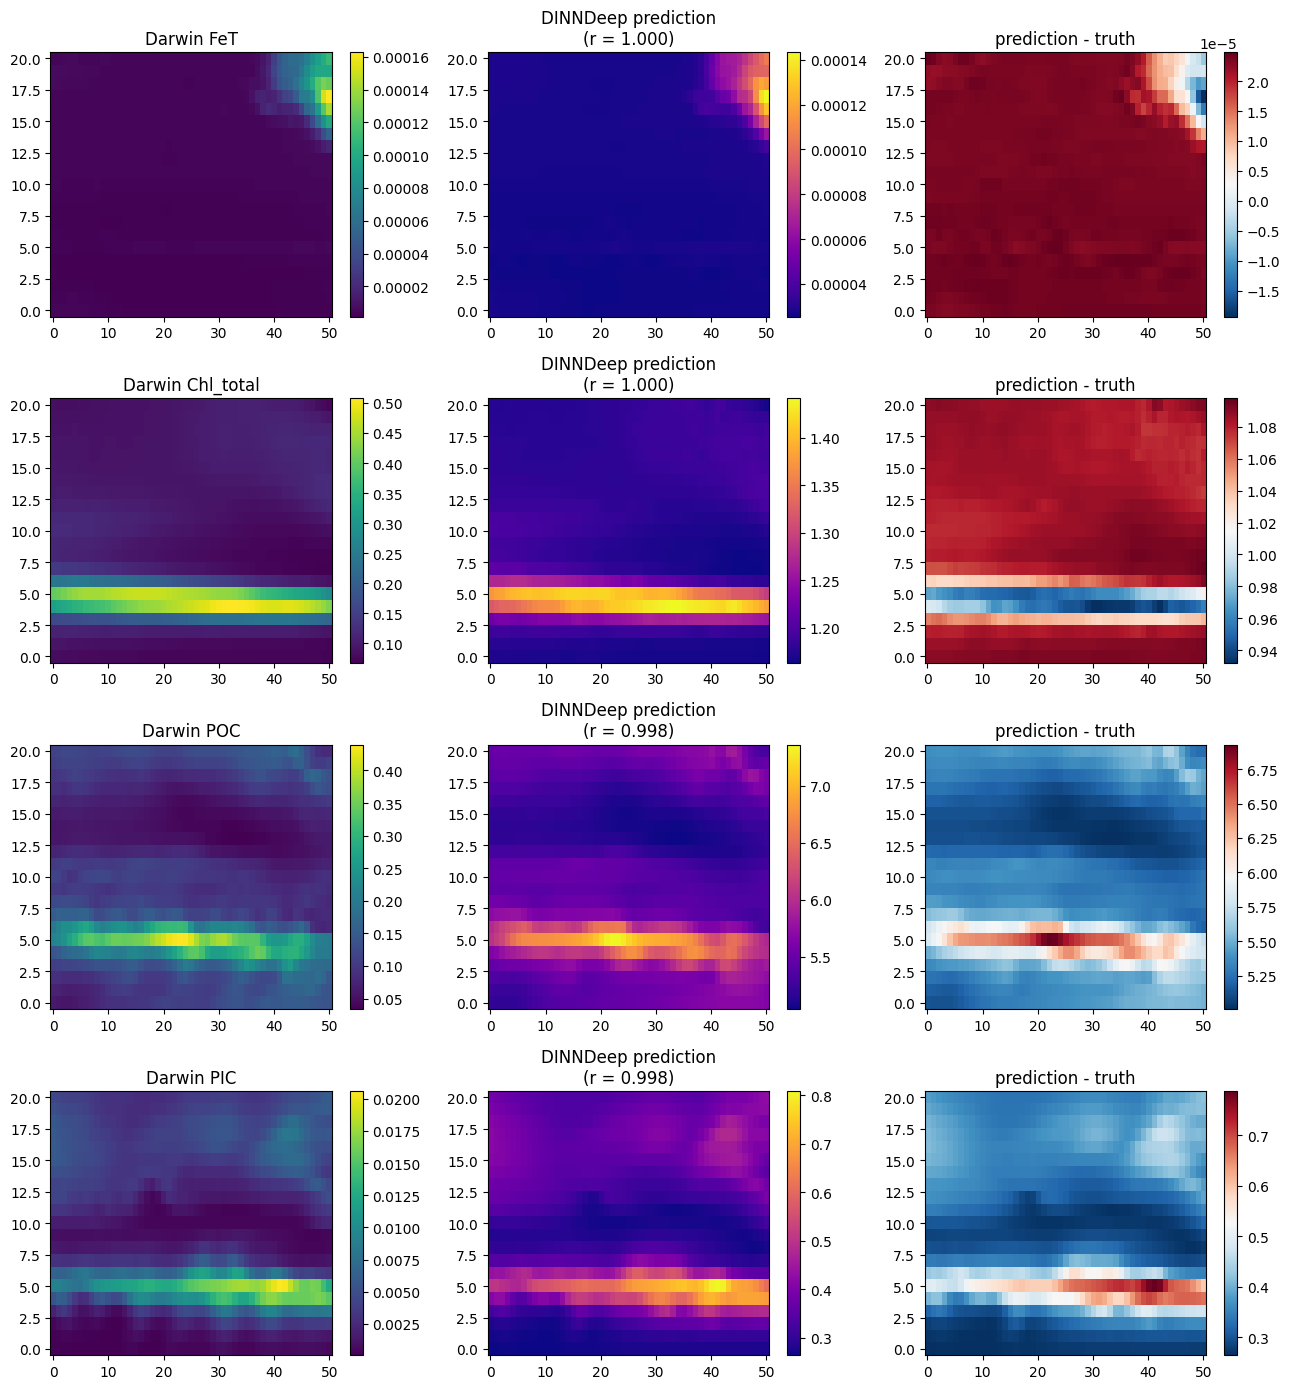

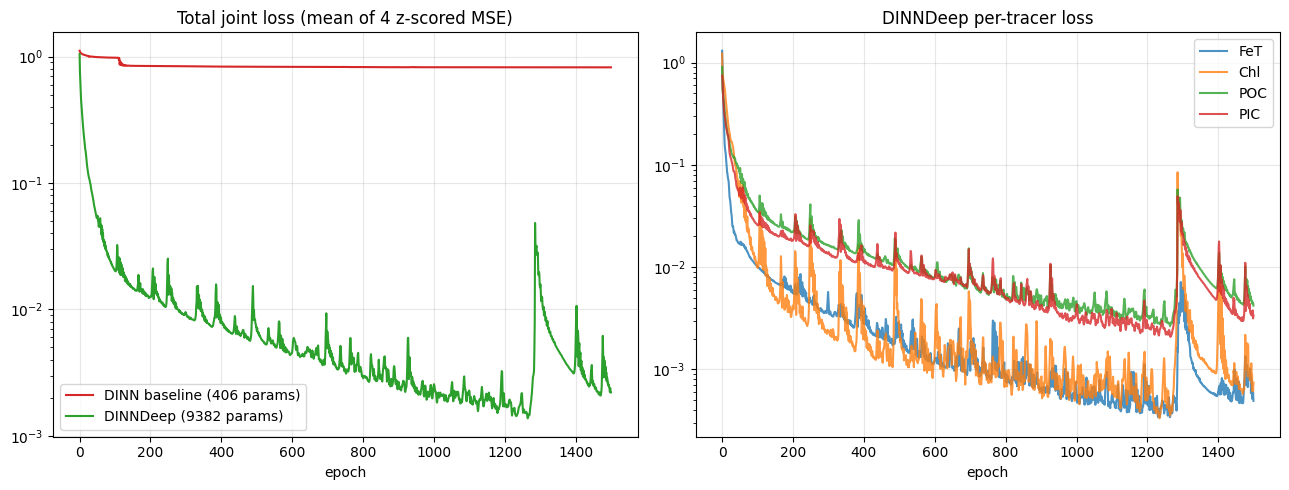

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
tracers = [
    ("FeT", fet_binned, r_deep["dfe_final"]),
    ("Chl_total", chl_total, r_deep["phyto_final"]),
    ("POC", poc_binned, r_deep["poc_final"]),
    ("PIC", pic_binned, r_deep["pic_final"]),
]

for row, (name, target, pred) in enumerate(tracers):
    target_plot = np.where(ocean_mask, target, np.nan)
    pred_plot = np.where(ocean_mask, pred, np.nan)
    err_plot = np.where(ocean_mask, pred - target, np.nan)

    im0 = axes[row, 0].imshow(target_plot, origin="lower", aspect="auto", cmap="viridis")
    axes[row, 0].set_title(f"Darwin {name}")
    plt.colorbar(im0, ax=axes[row, 0])

    rd = r_per_d[name if name != "Chl_total" else "Chl"]
    im1 = axes[row, 1].imshow(pred_plot, origin="lower", aspect="auto", cmap="plasma")
    axes[row, 1].set_title(f"DINNDeep prediction\n(r = {rd.r:.3f})")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(err_plot, origin="lower", aspect="auto", cmap="RdBu_r")
    axes[row, 2].set_title(f"prediction - truth")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.show()

# Loss curves: total + per-tracer
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogy(r_baseline["losses"], label=f"DINN baseline ({n_b} params)", color="tab:red")
axes[0].semilogy(r_deep["losses"], label=f"DINNDeep ({n_d} params)", color="tab:green")
axes[0].set_title("Total joint loss (mean of 4 z-scored MSE)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

for tracer in ["FeT", "Chl", "POC", "PIC"]:
    axes[1].semilogy(r_deep["losses_per_tracer"][tracer], label=tracer, alpha=0.8)
axes[1].set_title("DINNDeep per-tracer loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## What this notebook tests — and what to do with the result

Two questions, two decisions:

1. **Do all four tracer fields fit simultaneously?** If DINNDeep gets r ≈ 1.000 on every tracer (FeT, Chl, POC, PIC), the 5-tracer carroll6 box is *capable* of producing the joint Darwin tracer state — degeneracy is the only obstacle, and joint loss is the right tool to break it. If one or more tracer fits degrade significantly, the 4 tracers aren't simultaneously satisfiable with 6 free parameters + 5-tracer dynamics — that's a stronger statement of the structural ceiling than nb15 alone could make.

2. **Are recovered Carroll-6 means closer to Carroll's published values than nb15's single-target FeT result?**
   - **YES** → joint loss collapses the parameter degeneracy. Track 1 v1.8 result. The next-phase compute proposal becomes "scale this to full ocean / time-resolved" with cleaner identifiability.
   - **NO** → multi-tracer alone doesn't help; the ceiling is the box-model proxy itself. Box-model carbonate extension (nb20 candidate) becomes the unambiguous next priority.

**What stays unchanged regardless of outcome:**
- Per-cell architecture (1×1 conv backbone, no spatial coupling)
- Sigmoid bounding into Carroll's PARAM_BOUNDS
- Box model = carroll6 (5 tracers, no carbonate chem)
- Structural-ceiling argument (DINN class beats global-scalar)

## Where this fits in the project arc

- 09–14: SST-only DINN fits across (AOI × target) combos
- 15: DINNDeep saturation on Eq Pacific FeT (Track 1 v1.4)
- 16: cross-validation honesty check (Track 1 v1.5) — interpolation only
- 17: ensemble disagreement trust map (Track 1 v1.6) — outlier flag works, extrapolation flag fails
- 18: cross-basin DINNDeep on N Pacific Chl (Track 1 v1.7) — v1.4 partially generalises, mixed Carroll-6
- **19 (this notebook): multi-tracer joint loss on Eq Pacific** — Track 1 v1.8
- After this: depending on outcome, either (a) cluster transfer + scale-up, or (b) box-model carbonate extension (nb20), then cluster.
